# Forecast-Guided, Uncertainty-Aware Dimming Controller — KTP Demonstrator

This notebook is a **presentation-grade, end-to-end pipeline** for the intelligent dimming controller.

It is based on the research notebook where strategies were explored, but is intentionally **non-exploratory**: fixed configs, one run path, and clear outputs (KPIs + plots) suitable for KTP/industry review.

**Pipeline:** data → rolling-window ML runtime forecast → conformal residual buffer → control policy → actuation realism → KPIs.


## 0) Environment

Run in **Google Colab** or local Jupyter. If running in Colab, mount Drive to access your engineered CSV.

In [14]:
# If running in Google Colab, uncomment:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 250)
np.set_printoptions(suppress=True, floatmode='fixed', precision=3)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) Configuration (fixed for demonstrator)

In [16]:
# ---- Data ----
CSV_PATH = '/content/drive/MyDrive/BCU/THESIS/datasets/engineered_metadata.csv'  # <-- update as needed

FEATURES = [
    'avg_voltage', 'voltage_drop', 'voltage_gradient', 'voltage_std',
    'avg_current', 'max_current', 'current_std',
    'initial_temp', 'final_temp', 'temp_rise',
    'energy_approx', 'start_voltage', 'end_voltage'
]
TARGET = 'cycle_duration'  # seconds

USE_IQR_CLEANING = True

# ---- Forecasting (rolling-window) ----
MODEL_NAME = 'rf'          # kept simple for KTP demonstrator
TRAIN_SIZE = 500           # cycles
TEST_SIZE  = 50            # cycles
VAL_FRAC   = 0.15          # end-of-train validation fraction (time-aware)

# ---- Conformal buffer ----
ALPHA = 0.20               # q_{1-ALPHA} = q80(|residual|)

# ---- Dimming / standards-aware floors ----
PHASE_FLOORS = dict(active=60.0, quiet=30.0, predawn=20.0)
PHASE_SPLIT  = dict(active=0.4,  quiet=0.4,  predawn=0.2)

# ---- Actuation realism ----
HYSTERESIS = 5.0           # % deadband
RAMP_LIMIT = 10.0          # % per-step max change

# ---- Controller budgets & horizons ----
NIGHTS_H = [0.75, 1.0, 1.5]
BUDGETS  = [2.0, 5.0, 10.0]

# ---- Fixed / Block-fixed safety scan ----
S_GRID = np.linspace(0.75, 1.20, 91)

# ---- Adaptive controller ----
ADAPT_WINDOW = 200
ADAPT_KP     = 0.6
SAFETY_INIT  = 0.85


## 2) Load and prepare data

In [17]:
df_raw = pd.read_csv(CSV_PATH)

# Keep discharge cycles only (matches dissertation setup)
if 'type' in df_raw.columns:
    df_raw = df_raw[df_raw['type'].astype(str).str.lower().eq('discharge')].copy()

df_raw = df_raw[FEATURES + [TARGET]].dropna().reset_index(drop=True)

if USE_IQR_CLEANING:
    q1, q3 = df_raw[TARGET].quantile([0.25, 0.75])
    iqr = q3 - q1
    df = df_raw[(df_raw[TARGET] >= q1 - 1.5*iqr) & (df_raw[TARGET] <= q3 + 1.5*iqr)].copy()
else:
    df = df_raw.copy()

print(f'Dataset size: original={len(df_raw)} | used={len(df)} (IQR_clean={USE_IQR_CLEANING})')

X_all = df[FEATURES].values
y_all = df[TARGET].values.astype(float)


Dataset size: original=2794 | used=2141 (IQR_clean=True)


## 3) Rolling-window training (time-aware) + conformal buffer

In [18]:
def tune_rf_timeaware(X_train, y_train, val_frac=0.15, seed=SEED):
    """Very small RF grid tuned on an end-of-train validation block (time-aware)."""
    n = len(X_train)
    n_val = max(1, int(n * val_frac))
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]

    grid = []
    for md in (None, 12):
        for mleaf in (1, 3):
            for mf in ('sqrt', 'log2', 0.5):
                for n_est in (400, 700):
                    grid.append(dict(max_depth=md, min_samples_leaf=mleaf, max_features=mf, n_estimators=n_est))

    best_hp, best_mae = None, 1e18
    for hp in grid:
        m = RandomForestRegressor(**hp, n_jobs=-1, random_state=seed)
        m.fit(X_tr, y_tr)
        mae = mean_absolute_error(y_val, m.predict(X_val))
        if mae < best_mae:
            best_mae, best_hp = mae, hp
    return best_hp

def rolling_train_predict_with_buffer(X, y, train_size=500, test_size=50, val_frac=0.15, alpha=0.20):
    """
    Rolling window training: fit on [t-train_size, t), predict on [t, t+test_size).
    Conformal buffer q is computed from end-of-train validation residuals in each window.

    Returns
    -------
    y_hat_oos : np.ndarray, out-of-sample predictions (NaN where not predicted)
    q_global  : float, global quantile over all window validation residuals
    diag      : pd.DataFrame, per-window diagnostics
    """
    n = len(y)
    y_hat = np.full(n, np.nan, dtype=float)
    val_abs_resids = []
    rows = []

    start = train_size
    while start < n:
        end = min(n, start + test_size)
        X_train, y_train = X[start-train_size:start], y[start-train_size:start]
        X_test,  y_test  = X[start:end], y[start:end]

        hp = tune_rf_timeaware(X_train, y_train, val_frac=val_frac)
        model = RandomForestRegressor(**hp, n_jobs=-1, random_state=SEED)
        model.fit(X_train, y_train)

        # time-aware validation residuals (end of training)
        n_val = max(1, int(len(y_train) * val_frac))
        X_val, y_val = X_train[-n_val:], y_train[-n_val:]
        val_resid = y_val - model.predict(X_val)
        val_abs_resids.extend(np.abs(val_resid).tolist())

        # predict next block
        y_hat[start:end] = model.predict(X_test)

        # diagnostics
        mae_block = float(mean_absolute_error(y_test, y_hat[start:end])) if len(y_test) else np.nan
        q_local = float(np.quantile(np.abs(val_resid), 1 - alpha))
        rows.append(dict(train_end=start, test_end=end, mae_block=mae_block, q_local=q_local))

        start += test_size

    q_global = float(np.quantile(np.asarray(val_abs_resids), 1 - alpha)) if val_abs_resids else np.nan
    diag = pd.DataFrame(rows)
    return y_hat, q_global, diag

y_hat_all, q_alpha, diag = rolling_train_predict_with_buffer(
    X_all, y_all, train_size=TRAIN_SIZE, test_size=TEST_SIZE, val_frac=VAL_FRAC, alpha=ALPHA
)

# Keep only indices where we have out-of-sample predictions
mask = ~np.isnan(y_hat_all)
y_true = y_all[mask]
y_hat  = y_hat_all[mask]

print('Rolling forecast coverage:', mask.mean()*100, '%')
print('Global conformal buffer q_alpha (seconds):', round(q_alpha, 3))
display(diag.head())


Rolling forecast coverage: 76.64642690331621 %
Global conformal buffer q_alpha (seconds): 15.95


,train_end,test_end,mae_block,q_local
0,500,550,319.839660,6.960108
1,550,600,28.526387,19.184852
2,600,650,36.405405,14.929904
3,650,700,164.433501,4.059340
4,700,750,52.562240,13.780986


## 4) Helpers: floors, actuation constraints, metrics

In [19]:
def time_weighted_floor(floors, split):
    return (split['active']*floors['active'] +
            split['quiet'] *floors['quiet']  +
            split['predawn']*floors['predawn'])

def ml_pct_from_forecast(y_hat, T, safety, qbuf, floors, split):
    # conservative runtime (forecast minus conformal buffer)
    safe_runtime = np.maximum(0.0, y_hat - qbuf)
    pct_raw = 100.0 * safety * (safe_runtime / T)
    floor_avg = time_weighted_floor(floors, split)
    return np.clip(pct_raw, floor_avg, 100.0)

def apply_hysteresis_and_ramp(pct, hysteresis=HYSTERESIS, ramp=RAMP_LIMIT, min_pct=0.0, max_pct=100.0):
    pct = np.asarray(pct, float)
    if pct.size == 0:
        return pct
    out = np.zeros_like(pct)
    out[0] = np.clip(pct[0], min_pct, max_pct)
    for i in range(1, len(pct)):
        delta = pct[i] - out[i-1]
        # hysteresis: ignore small changes; ramp-limit large changes
        desired = out[i-1] if abs(delta) < hysteresis else out[i-1] + np.clip(delta, -ramp, ramp)
        out[i] = np.clip(desired, min_pct, max_pct)
    return out

def simulate_metrics(pct, T, y_true):
    pct = np.asarray(pct, float)
    achievable = y_true * (100.0 / pct)
    blackout = achievable < T
    unmet = np.maximum(0.0, T - achievable) / 60.0
    return dict(
        blackout_rate=float(blackout.mean()*100.0),
        energy_saving=float(100.0 - np.mean(pct)),
        mean_pct=float(np.mean(pct)),
        unmet_minutes=float(np.mean(unmet)),
    )


## 5) Controllers (as in your strategy notebook)

In [20]:
# 5.1 Rule baseline (voltage-score → {100,70,40}%)
def rule_setpoints(df_sub, hysteresis=HYSTERESIS, ramp=RAMP_LIMIT):
    sv, ev = df_sub['start_voltage'].values, df_sub['end_voltage'].values
    svn = (sv - sv.min()) / (sv.max() - sv.min() + 1e-9)
    evn = (ev - ev.min()) / (ev.max() - ev.min() + 1e-9)
    score = 0.7*svn + 0.3*evn

    def bucket(v):
        if v >= 0.66: return 100.0
        if v >= 0.33: return 70.0
        return 40.0

    pct = np.array([bucket(v) for v in score], float)
    return apply_hysteresis_and_ramp(pct, hysteresis, ramp)

# 5.2 Fixed-safety ML: choose safety s from grid to meet blackout budget
def choose_fixed_safety(y_true, y_hat, T, qbuf, floors, split, budget, s_grid=S_GRID):
    best = None
    for s in s_grid:
        pct = ml_pct_from_forecast(y_hat, T, s, qbuf, floors, split)
        pct = apply_hysteresis_and_ramp(pct)
        m = simulate_metrics(pct, T, y_true)
        if m['blackout_rate'] <= budget:
            best = (s, pct, m)
            break
    if best is None:
        s = s_grid[-1]
        pct = apply_hysteresis_and_ramp(ml_pct_from_forecast(y_hat, T, s, qbuf, floors, split))
        m = simulate_metrics(pct, T, y_true)
        best = (s, pct, m)
    return best

# 5.3 Block-fixed ML: re-select s per block of B cycles
def block_fixed_controller(y_true, y_hat, T, qbuf, floors, split, budget, B=30):
    n = len(y_true)
    pct_out = np.zeros(n, float)
    for i in range(0, n, B):
        j = min(n, i+B)
        s, pct_block, _ = choose_fixed_safety(y_true[i:j], y_hat[i:j], T, qbuf, floors, split, budget)
        pct_out[i:j] = pct_block
    pct_out = apply_hysteresis_and_ramp(pct_out)
    m = simulate_metrics(pct_out, T, y_true)
    return pct_out, m

# 5.4 Adaptive ML: proportional update to track blackout-rate budget
def adaptive_controller(y_true, y_hat, T, qbuf, floors, split,
                        budget=5.0, s_init=SAFETY_INIT, k_p=ADAPT_KP, window=ADAPT_WINDOW):
    n = len(y_true)
    s_hist = np.zeros(n, float)
    pct_out = np.zeros(n, float)
    s = float(s_init)

    blackouts = np.zeros(n, bool)
    for t in range(n):
        pct_t = ml_pct_from_forecast(np.array([y_hat[t]]), T, s, qbuf, floors, split)[0]
        pct_out[t] = pct_t

        achievable = y_true[t] * (100.0 / pct_t)
        blackouts[t] = achievable < T

        a = max(0, t-window+1)
        br = blackouts[a:t+1].mean() * 100.0

        # proportional update on blackout-budget error
        err = br - budget
        s = np.clip(s - k_p*(err/100.0), 0.70, 1.20)
        s_hist[t] = s

    pct_out = apply_hysteresis_and_ramp(pct_out)
    m = simulate_metrics(pct_out, T, y_true)
    return s_hist, pct_out, m


## 6) Demonstrator run (one horizon + budget)

,Policy,Night_h,Budget,blackout_rate,energy_saving,mean_pct,unmet_minutes,Safety
0,Rule,1.0,5.0,97.074954,0.798294,99.201706,12.531228,NaN
1,ML fixed,1.0,5.0,2.925046,39.470219,60.529781,0.221002,0.75
2,ML block-fixed (B=30),1.0,5.0,6.825107,37.111206,62.888794,1.154835,NaN
3,ML adaptive,1.0,5.0,10.237660,40.597989,59.402011,0.514376,NaN


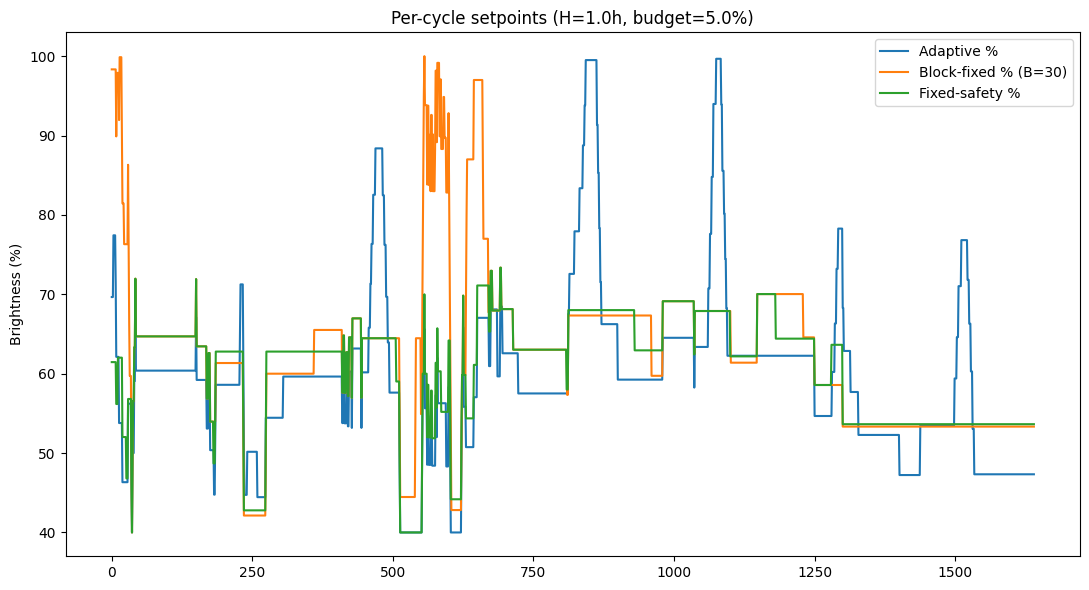

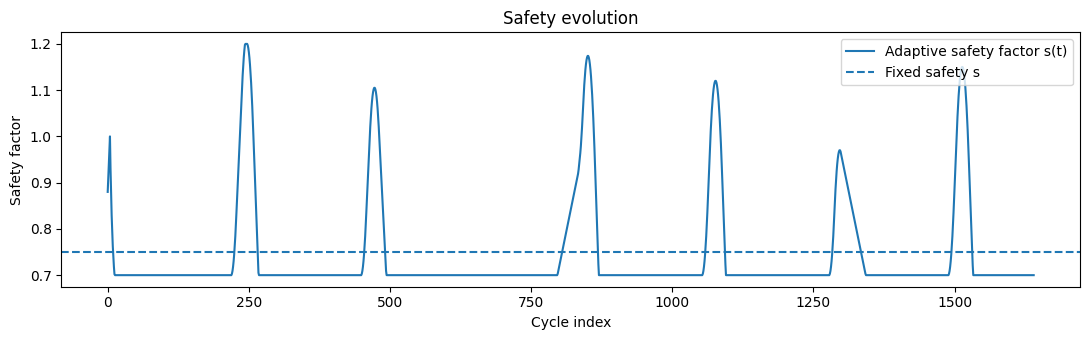

In [21]:
H = 1.0
BUDGET = 5.0
T = H * 3600.0

# Rule (needs df aligned with mask indices)
df_pred = df.loc[mask].reset_index(drop=True)
pct_rule = rule_setpoints(df_pred)
m_rule = simulate_metrics(pct_rule, T, y_true)

# Fixed safety
s_fixed, pct_fixed, m_fixed = choose_fixed_safety(y_true, y_hat, T, q_alpha, PHASE_FLOORS, PHASE_SPLIT, BUDGET)

# Block-fixed
pct_block, m_block = block_fixed_controller(y_true, y_hat, T, q_alpha, PHASE_FLOORS, PHASE_SPLIT, BUDGET, B=30)

# Adaptive
s_hist, pct_adapt, m_adapt = adaptive_controller(y_true, y_hat, T, q_alpha, PHASE_FLOORS, PHASE_SPLIT, budget=BUDGET)

results = pd.DataFrame([
    dict(Policy='Rule', Night_h=H, Budget=BUDGET, **m_rule),
    dict(Policy='ML fixed', Night_h=H, Budget=BUDGET, Safety=s_fixed, **m_fixed),
    dict(Policy='ML block-fixed (B=30)', Night_h=H, Budget=BUDGET, **m_block),
    dict(Policy='ML adaptive', Night_h=H, Budget=BUDGET, **m_adapt),
])
display(results)

plt.figure(figsize=(11,6))
plt.plot(pct_adapt, label='Adaptive %')
plt.plot(pct_block, label='Block-fixed % (B=30)')
plt.plot(pct_fixed, label='Fixed-safety %')
plt.ylabel('Brightness (%)')
plt.title(f'Per-cycle setpoints (H={H}h, budget={BUDGET}%)')
plt.legend()
plt.tight_layout();
plt.show()

plt.figure(figsize=(11,3.5))
plt.plot(s_hist, label='Adaptive safety factor s(t)')
plt.axhline(s_fixed, ls='--', label='Fixed safety s')
plt.ylabel('Safety factor')
plt.xlabel('Cycle index')
plt.title('Safety evolution')
plt.legend();
plt.tight_layout();
plt.show()


## 7) Trade-off sweep (night lengths × budgets)

,Night_h,Budget,Policy,Blackout,Saving,Safety
3,0.75,2.0,ML adaptive,5.240707,17.938040,NaN
6,0.75,5.0,ML adaptive,7.678245,18.298082,NaN
9,0.75,10.0,ML adaptive,10.420475,14.534954,NaN
2,0.75,2.0,ML block-fixed (B=30),6.459476,16.341082,NaN
5,0.75,5.0,ML block-fixed (B=30),4.509445,17.882768,NaN
8,0.75,10.0,ML block-fixed (B=30),3.107861,18.868065,NaN
1,0.75,2.0,ML fixed,29.616088,2.289318,1.20
4,0.75,5.0,ML fixed,2.925046,20.026373,0.75
7,0.75,10.0,ML fixed,2.925046,20.026373,0.75
0,0.75,NaN,Rule,29.737965,0.798294,NaN


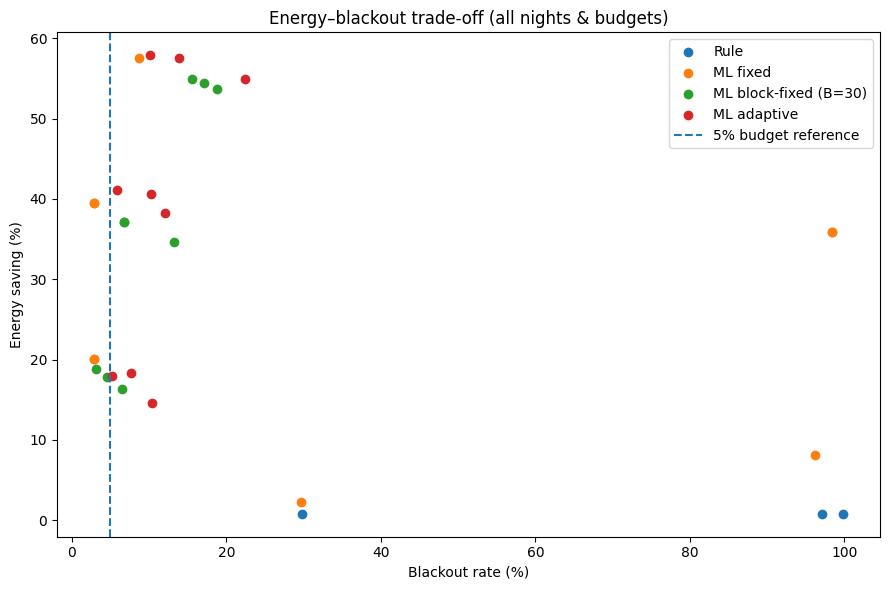

In [22]:
rows = []

for H in NIGHTS_H:
    T = H * 3600.0

    # Rule baseline (same for all budgets)
    pct_rule = rule_setpoints(df_pred)
    m_rule = simulate_metrics(pct_rule, T, y_true)
    rows.append(dict(Night_h=H, Budget=np.nan, Policy='Rule', Blackout=m_rule['blackout_rate'], Saving=m_rule['energy_saving']))

    for bud in BUDGETS:
        # Fixed
        s, pct, m = choose_fixed_safety(y_true, y_hat, T, q_alpha, PHASE_FLOORS, PHASE_SPLIT, bud)
        rows.append(dict(Night_h=H, Budget=bud, Policy='ML fixed', Safety=s, Blackout=m['blackout_rate'], Saving=m['energy_saving']))

        # Block-fixed
        pct_b, m_b = block_fixed_controller(y_true, y_hat, T, q_alpha, PHASE_FLOORS, PHASE_SPLIT, bud, B=30)
        rows.append(dict(Night_h=H, Budget=bud, Policy='ML block-fixed (B=30)', Safety=np.nan, Blackout=m_b['blackout_rate'], Saving=m_b['energy_saving']))

        # Adaptive
        _, pct_a, m_a = adaptive_controller(y_true, y_hat, T, q_alpha, PHASE_FLOORS, PHASE_SPLIT, budget=bud)
        rows.append(dict(Night_h=H, Budget=bud, Policy='ML adaptive', Safety=np.nan, Blackout=m_a['blackout_rate'], Saving=m_a['energy_saving']))

trade = pd.DataFrame(rows)
display(trade.sort_values(['Night_h','Policy','Budget']).head(20))

plt.figure(figsize=(9,6))
for pol in trade['Policy'].unique():
    sub = trade[trade['Policy'] == pol]
    plt.scatter(sub['Blackout'], sub['Saving'], label=pol)
plt.axvline(5.0, ls='--', label='5% budget reference')
plt.xlabel('Blackout rate (%)')
plt.ylabel('Energy saving (%)')
plt.title('Energy–blackout trade-off (all nights & budgets)')
plt.legend()
plt.tight_layout();
plt.show()
